# Exercise - SAR Prediction in VHP Head Model- investigating new methods/Using new database (4)


Exercise in the lecture Machine Learning in Electrical Engineering and Information Technology, Prediction of the Specific Absorption Rate (SAR)

* Lecture Period: Summer 2026 ([StudIP](https://e-learning.tuhh.de/studip/dispatch.php/course/details/index/1be148fc0ce85172e3902adf814a909b))
* Institute: Institut für Theoretische Elektrotechnik ([TET](https://www.tet.tuhh.de/en/))
* University: Hamburg University of Technology ([TUHH](https://www.tuhh.de/tuhh/en/startpage))
* Exercise Supervisor: Malte Thode


The fourth part of the exercise is about the prediction of the Specific Absorption Rate (SAR) inside a human head model with a new database which show the SAR results in each tissue only inspired by scattered electric field instead of total electric field. The results are physically wrong since the whole amound of electric field in each tissue is not considered in calculating the SAR. Again the human head model consists of multiple tissues that vary in their electromagnetic properties. The prediction is to be carried out for multiple tissues simultaneously. 
Try to work with new database and use what you have learned in prevoius tasks and see how good the prediction results could be for this new database.



#### Module Import
**Modules** are imported, which have to be available to the python interpreter.  
**helper_functions (hp)** is a module in the working directory providing some functions making the notebook more tidy.

**Module Links for Further Information:**
* [pandas](https://pandas.pydata.org/)
* [numpy](https://numpy.org/)
* [matplotlib](https://matplotlib.org/)
* [pickle](https://docs.python.org/3/library/pickle.html)
* [scikit-learn](https://scikit-learn.org/stable/index.html)

In [1]:
# Required modules
from time import perf_counter
from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor, HistGradientBoostingRegressor)
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from scipy.stats import pearsonr, loguniform, randint, uniform
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
import sklearn.metrics as sm
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")


#### Load Data from Working Directory

From the local directory the CSV file is loaded. The electric properties of the different tissues are varied and given in the table. The ***conductivity*** and ***relative permitivitty*** of each tissue represent the ***input features***. The resulting ***SAR*** in the different tissues after simulation represent the ***output*** features.
Use the given data and try to implement ANNs which give a good prediction on results.


**Variables:**

* *file_name* &rarr; file containing the data

In [2]:
# Reproducible experiment settings
file_name = "data/task_4.csv"
test_size = 0.20
random_state = 42


#### Guiding Questions and Investigation Plan

This notebook answers the original questions by first inspecting the new database, then comparing simple, neural-network, kernel, and tree/boosting methods with training-only cross-validation. Exactly one model is selected before the untouched test set is evaluated.


#### Load and Verify the Actual Task-4 Database

Columns are selected programmatically. The raw CSV remains unchanged; SAR targets are copied and converted from W/kg to mW/kg.


In [3]:
data_set = pd.read_csv(file_name)
pd.set_option("display.max_columns", None)

input_columns = [c for c in data_set.columns if c.startswith(("Eps_", "Cond_"))]
sar_columns_wkg = [c for c in data_set.columns if c.startswith("SAR_")]

X = data_set.loc[:, input_columns].astype(float).copy()
Y = data_set.loc[:, sar_columns_wkg].astype(float).copy() * 1000.0
Y.columns = [c.replace("(W/kG)", "(mW/kg)") for c in sar_columns_wkg]
tissue_names = [c.removeprefix("SAR_").replace("(mW/kg)", "") for c in Y.columns]

print("Dataset shape:", data_set.shape)
display(data_set.head())
print("All columns:", data_set.columns.tolist())
print("Samples / inputs / outputs:", len(X), X.shape[1], Y.shape[1])
print("Missing values:", int(data_set.isna().sum().sum()))
print("Duplicate rows:", int(data_set.duplicated().sum()))

assert data_set.shape == (500, 42)
assert X.shape == (500, 28) and Y.shape == (500, 14)
assert not any(c.startswith("SAR_") for c in X.columns)
assert not data_set.isna().any().any()
assert not data_set.duplicated().any()


Dataset shape: (500, 42)


,Eps_blood,Eps_bodyAverage,Eps_boneCortical,Eps_brainGreyMatter,Eps_brainWhiteMatter,Eps_cartilage,Eps_cerebellum,Eps_cerebrospinalFluid,Eps_eyeVitrousHumor,Eps_fatAverageInfiltrated,Eps_nerve,Eps_skin,Eps_tongue,Eps_tooth,Cond_blood(S/m),Cond_bodyAverage(S/m),Cond_boneCortical(S/m),Cond_brainGreyMatter(S/m),Cond_brainWhiteMatter(S/m),Cond_cartilage(S/m),Cond_cerebellum(S/m),Cond_cerebrospinalFluid(S/m),Cond_eyeVitrousHumor(S/m),Cond_fatAverageInfiltrated(S/m),Cond_nerve(S/m),Cond_skin(S/m),Cond_tongue(S/m),Cond_tooth(S/m),SAR_blood(W/kG),SAR_bodyAverage(W/kG),SAR_boneCortical(W/kG),SAR_brainGreyMatter(W/kG),SAR_brainWhiteMatter(W/kG),SAR_cartilage(W/kG),SAR_cerebellum(W/kG),SAR_cerebrospinalFluid(W/kG),SAR_eyeVitrousHumor(W/kG),SAR_fatAverageInfiltrated(W/kG),SAR_nerve(W/kG),SAR_skin(W/kG),SAR_tongue(W/kG),SAR_tooth(W/kG)
0,202.391943,162.772738,32.082537,282.664792,169.226056,140.299739,327.369236,121.577327,55.896623,21.177736,113.368230,329.200274,166.171338,28.823285,1.014663,0.692258,0.041664,0.282357,0.182171,0.413927,0.423462,1.618978,1.262529,0.064573,0.265206,0.280607,0.592796,0.043619,0.000482,0.000316,0.000011,0.000134,0.000087,0.000376,0.000201,0.001603,0.000626,0.000035,0.000123,0.000125,0.000271,0.000010
1,220.140963,154.677420,33.059971,313.723949,127.040446,124.842133,432.882209,108.597915,67.030603,20.383905,117.128459,278.808764,178.136169,27.026812,1.194805,0.545036,0.054263,0.316815,0.171724,0.415901,0.452454,1.780904,1.512874,0.061679,0.270251,0.218381,0.465970,0.038636,0.000568,0.000249,0.000014,0.000151,0.000082,0.000377,0.000215,0.001763,0.000751,0.000033,0.000125,0.000098,0.000213,0.000009
2,237.063196,159.168263,35.854276,262.862911,139.042792,153.889445,359.383801,109.602525,73.384337,20.315292,132.433957,250.173858,138.771861,27.988484,1.075694,0.700899,0.044376,0.296611,0.154650,0.355592,0.351448,2.137172,1.518003,0.046758,0.259674,0.283296,0.600579,0.053049,0.000511,0.000320,0.000011,0.000141,0.000074,0.000323,0.000167,0.002117,0.000754,0.000025,0.000121,0.000127,0.000275,0.000012
3,214.075550,129.674204,26.808675,301.503291,148.862083,128.376015,399.338394,90.902227,82.040494,20.337613,121.391231,293.801450,184.239447,33.880018,1.331646,0.734935,0.046381,0.368760,0.174588,0.323879,0.471536,1.917049,1.373118,0.057482,0.189541,0.256987,0.534088,0.039309,0.000633,0.000336,0.000012,0.000176,0.000083,0.000294,0.000224,0.001899,0.000682,0.000031,0.000088,0.000115,0.000244,0.000009
4,234.050216,128.394947,36.469080,257.097011,161.436842,117.498801,425.263889,98.981348,56.687026,25.937467,144.621412,248.880741,154.366171,32.981863,0.998273,0.715141,0.044822,0.334314,0.193343,0.333434,0.515890,1.631623,1.450680,0.057677,0.273974,0.200360,0.624696,0.041897,0.000475,0.000327,0.000012,0.000159,0.000092,0.000303,0.000245,0.001616,0.000720,0.000031,0.000127,0.000089,0.000286,0.000010


All columns: ['Eps_blood', 'Eps_bodyAverage', 'Eps_boneCortical', 'Eps_brainGreyMatter', 'Eps_brainWhiteMatter', 'Eps_cartilage', 'Eps_cerebellum', 'Eps_cerebrospinalFluid', 'Eps_eyeVitrousHumor', 'Eps_fatAverageInfiltrated', 'Eps_nerve', 'Eps_skin', 'Eps_tongue', 'Eps_tooth', 'Cond_blood(S/m)', 'Cond_bodyAverage(S/m)', 'Cond_boneCortical(S/m)', 'Cond_brainGreyMatter(S/m)', 'Cond_brainWhiteMatter(S/m)', 'Cond_cartilage(S/m)', 'Cond_cerebellum(S/m)', 'Cond_cerebrospinalFluid(S/m)', 'Cond_eyeVitrousHumor(S/m)', 'Cond_fatAverageInfiltrated(S/m)', 'Cond_nerve(S/m)', 'Cond_skin(S/m)', 'Cond_tongue(S/m)', 'Cond_tooth(S/m)', 'SAR_blood(W/kG)', 'SAR_bodyAverage(W/kG)', 'SAR_boneCortical(W/kG)', 'SAR_brainGreyMatter(W/kG)', 'SAR_brainWhiteMatter(W/kG)', 'SAR_cartilage(W/kG)', 'SAR_cerebellum(W/kG)', 'SAR_cerebrospinalFluid(W/kG)', 'SAR_eyeVitrousHumor(W/kG)', 'SAR_fatAverageInfiltrated(W/kG)', 'SAR_nerve(W/kG)', 'SAR_skin(W/kG)', 'SAR_tongue(W/kG)', 'SAR_tooth(W/kG)']
Samples / inputs / outputs

#### Physical Difference from Task 3

**Task 3:** 28 tissue material parameters â†’ SAR based on the physically meaningful **total electric field** â†’ 14 tissue outputs.

**Task 4:** the same type of 28 material parameters â†’ SAR calculated using only the **scattered electric field** â†’ 14 tissue outputs.

The Task-4 targets omit part of the field required for the complete SAR calculation and are therefore physically problematic. This may weaken their useful relationship with the supplied material parameters, but it does not make statistical learning mathematically impossible; the following analysis tests learnability empirically.


In [4]:
# One reproducible split. Test data are set aside until all CV decisions are complete.
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=test_size, random_state=random_state, shuffle=True
)
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

print("Training samples:", len(X_train))
print("Untouched test samples:", len(X_test))


Training samples: 400
Untouched test samples: 100


#### Data-Relationship Analysis

We examine output coupling, each tissue's relationship to its own conductivity and permittivity, the strongest marginal input correlation available for each target, and target ranges. Correlation is descriptive and does not establish causality.


,Tissue,"Corr(SAR, own conductivity)","Corr(SAR, own permittivity)",Maximum absolute input-SAR correlation,Input at maximum
0,blood,0.3618,0.0033,0.3618,Cond_blood(S/m)
1,bodyAverage,0.3593,-0.0354,0.3593,Cond_bodyAverage(S/m)
2,boneCortical,0.3542,-0.0302,0.3542,Cond_boneCortical(S/m)
3,brainGreyMatter,0.3957,0.0332,0.3957,Cond_brainGreyMatter(S/m)
4,brainWhiteMatter,0.4392,-0.0580,0.4392,Cond_brainWhiteMatter(S/m)
5,cartilage,0.4277,-0.0029,0.4277,Cond_cartilage(S/m)
6,cerebellum,0.4715,-0.0368,0.4715,Cond_cerebellum(S/m)
7,cerebrospinalFluid,0.4569,0.0454,0.4569,Cond_cerebrospinalFluid(S/m)
8,eyeVitrousHumor,0.3790,-0.0283,0.3790,Cond_eyeVitrousHumor(S/m)
9,fatAverageInfiltrated,0.3543,-0.0079,0.3543,Cond_fatAverageInfiltrated(S/m)


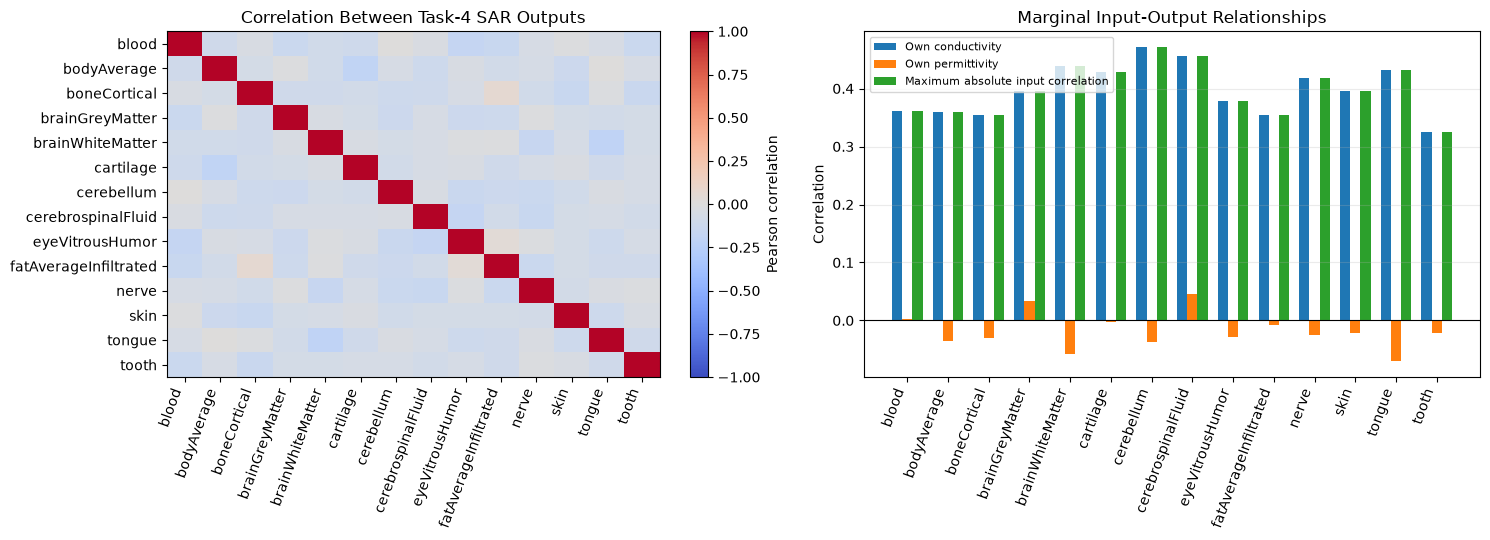

,Output,min,max,mean,std
0,SAR_blood(mW/kg),0.425543,0.636912,0.533913,0.063921
1,SAR_bodyAverage(mW/kg),0.230503,0.344497,0.286966,0.033762
2,SAR_boneCortical(mW/kg),0.009332,0.014114,0.011689,0.001383
3,SAR_brainGreyMatter(mW/kg),0.124560,0.187167,0.155369,0.017870
4,SAR_brainWhiteMatter(mW/kg),0.066876,0.100388,0.083428,0.009603
5,SAR_cartilage(mW/kg),0.277714,0.416542,0.347852,0.040135
6,SAR_cerebellum(mW/kg),0.165110,0.248131,0.207491,0.024737
7,SAR_cerebrospinalFluid(mW/kg),1.588025,2.382925,1.992905,0.241327
8,SAR_eyeVitrousHumor(mW/kg),0.596935,0.894183,0.746721,0.086253
9,SAR_fatAverageInfiltrated(mW/kg),0.023801,0.035968,0.029773,0.003402


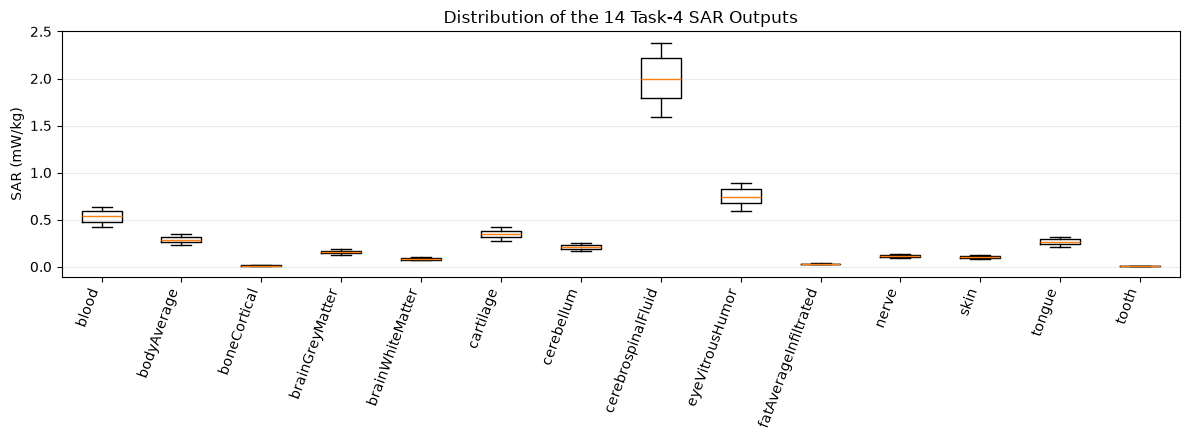

Mean absolute off-diagonal output correlation: 0.0786
Maximum absolute off-diagonal output correlation: 0.1953


In [5]:
# Output-output correlations.
output_corr = Y.corr()
mask = ~np.eye(len(output_corr), dtype=bool)
mean_abs_output_corr = np.abs(output_corr.to_numpy()[mask]).mean()
max_abs_output_corr = np.abs(output_corr.to_numpy()[mask]).max()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
image = axes[0].imshow(output_corr, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
axes[0].set_xticks(range(14), tissue_names, rotation=70, ha="right")
axes[0].set_yticks(range(14), tissue_names)
axes[0].set_title("Correlation Between Task-4 SAR Outputs")
fig.colorbar(image, ax=axes[0], label="Pearson correlation")

# Per-tissue own-property and maximum input-output correlations.
relationship_rows = []
for tissue, target in zip(tissue_names, Y.columns):
    eps_col = f"Eps_{tissue}"
    cond_col = f"Cond_{tissue}(S/m)"
    correlations = X.corrwith(Y[target])
    relationship_rows.append({
        "Tissue": tissue,
        "Corr(SAR, own conductivity)": Y[target].corr(X[cond_col]),
        "Corr(SAR, own permittivity)": Y[target].corr(X[eps_col]),
        "Maximum absolute input-SAR correlation": correlations.abs().max(),
        "Input at maximum": correlations.abs().idxmax(),
    })
relationship_table = pd.DataFrame(relationship_rows)
display(relationship_table.style.format(precision=4))

axes[1].bar(np.arange(14) - 0.25, relationship_table["Corr(SAR, own conductivity)"],
            width=0.25, label="Own conductivity")
axes[1].bar(np.arange(14), relationship_table["Corr(SAR, own permittivity)"],
            width=0.25, label="Own permittivity")
axes[1].bar(np.arange(14) + 0.25, relationship_table["Maximum absolute input-SAR correlation"],
            width=0.25, label="Maximum absolute input correlation")
axes[1].set_xticks(range(14), tissue_names, rotation=70, ha="right")
axes[1].set_ylabel("Correlation")
axes[1].set_title("Marginal Input-Output Relationships")
axes[1].axhline(0, color="black", lw=0.8); axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

range_table = Y.agg(["min", "max", "mean", "std"]).T.reset_index(names="Output")
display(range_table.style.format(precision=6))
plt.figure(figsize=(12, 4.5))
plt.boxplot([Y[c] for c in Y.columns], showfliers=False)
plt.xticks(np.arange(1, 15), tissue_names, rotation=70, ha="right")
plt.ylabel("SAR (mW/kg)"); plt.title("Distribution of the 14 Task-4 SAR Outputs")
plt.grid(axis="y", alpha=0.25); plt.tight_layout(); plt.show()

print(f"Mean absolute off-diagonal output correlation: {mean_abs_output_corr:.4f}")
print(f"Maximum absolute off-diagonal output correlation: {max_abs_output_corr:.4f}")


#### Simple Baselines and Per-Tissue Cross-Validated RÂ²

The mean predictor establishes the no-skill reference. Ridge tests whether a stable approximately linear mapping exists. All predictions below are out-of-fold predictions for the 400 training samples.


In [6]:
mean_model = DummyRegressor(strategy="mean")
ridge_model = Pipeline([
    ("input_scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])

baseline_rows = []
for name, model in {"Mean predictor": mean_model, "Ridge": ridge_model}.items():
    oof = cross_val_predict(model, X_train, Y_train, cv=cv, n_jobs=1)
    per_tissue = sm.r2_score(Y_train, oof, multioutput="raw_values")
    for tissue, score in zip(tissue_names, per_tissue):
        baseline_rows.append({"Model": name, "Tissue": tissue, "CV R2": score})
baseline_tissue_r2 = pd.DataFrame(baseline_rows)
baseline_pivot = baseline_tissue_r2.pivot(index="Tissue", columns="Model", values="CV R2")
display(baseline_pivot.style.format(precision=5))
print("Macro out-of-fold R2 by simple baseline:")
print(baseline_tissue_r2.groupby("Model")["CV R2"].mean())


Model,Mean predictor,Ridge
Tissue,,
blood,-0.00437,0.06953
bodyAverage,-0.00460,0.03207
boneCortical,-0.00875,-0.01838
brainGreyMatter,-0.00410,0.05919
brainWhiteMatter,-0.00461,0.12282
cartilage,-0.00486,0.08024
cerebellum,-0.01286,0.16068
cerebrospinalFluid,-0.00772,0.13370
eyeVitrousHumor,-0.00568,0.06079


Macro out-of-fold R2 by simple baseline:
Model
Mean predictor   -0.005961
Ridge             0.070356
Name: CV R2, dtype: float64


#### Task-3-Style ANN Baseline, Scaling Choice, and Full Hypertuning

The original **28 â†’ 5 â†’ 14** ANN is retained. Input-only scaling is compared with leakage-safe input-and-target scaling using the same five training folds. The better strategy is then used in a 30-combination `RandomizedSearchCV`; the 100 test samples are not used in either decision.


In [7]:
baseline_ann_params = dict(
    hidden_layer_sizes=(5,), activation="tanh", solver="adam",
    learning_rate_init=1e-2, alpha=1e-4, max_iter=20000,
    early_stopping=True, n_iter_no_change=50, tol=1e-5,
    random_state=random_state,
)
joint_mlp_raw = Pipeline([
    ("input_scaler", StandardScaler()),
    ("mlp", MLPRegressor(**baseline_ann_params)),
])
joint_mlp_scaled_y = TransformedTargetRegressor(
    regressor=Pipeline([
        ("input_scaler", StandardScaler()),
        ("mlp", MLPRegressor(**baseline_ann_params)),
    ]),
    transformer=StandardScaler(),
)
independent_mlp = MultiOutputRegressor(Pipeline([
    ("input_scaler", StandardScaler()),
    ("mlp", MLPRegressor(**baseline_ann_params)),
]), n_jobs=1)

baseline_ann_cv_raw = cross_val_score(
    joint_mlp_raw, X_train, Y_train, cv=cv, scoring="r2", n_jobs=1
)
baseline_ann_cv_scaled = cross_val_score(
    joint_mlp_scaled_y, X_train, Y_train, cv=cv, scoring="r2", n_jobs=1
)
independent_ann_cv = cross_val_score(
    independent_mlp, X_train, Y_train, cv=cv, scoring="r2", n_jobs=1
)
ann_uses_target_scaling = baseline_ann_cv_scaled.mean() > baseline_ann_cv_raw.mean()
selected_ann_baseline = joint_mlp_scaled_y if ann_uses_target_scaling else joint_mlp_raw
baseline_ann_cv = baseline_ann_cv_scaled if ann_uses_target_scaling else baseline_ann_cv_raw

print("Baseline ANN topology: 28 -> 5 -> 14")
print(f"Baseline CV R2 without target scaling: {baseline_ann_cv_raw.mean():.6f} +/- {baseline_ann_cv_raw.std():.6f}")
print(f"Baseline CV R2 with target scaling:    {baseline_ann_cv_scaled.mean():.6f} +/- {baseline_ann_cv_scaled.std():.6f}")
print(f"Independent-ANN mean CV R2:            {independent_ann_cv.mean():.6f}")
print("Scaling strategy selected for ANN tuning:",
      "X + Y scaling" if ann_uses_target_scaling else "X scaling only")

search_pipeline = Pipeline([
    ("input_scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        solver="adam", max_iter=20000, early_stopping=True,
        n_iter_no_change=50, tol=1e-5, random_state=random_state,
    )),
])
if ann_uses_target_scaling:
    ann_search_estimator = TransformedTargetRegressor(
        regressor=search_pipeline, transformer=StandardScaler()
    )
    ann_prefix = "regressor__mlp__"
else:
    ann_search_estimator = search_pipeline
    ann_prefix = "mlp__"

ann_parameter_distributions = {
    ann_prefix + "hidden_layer_sizes": [
        (5,), (10,), (20,), (40,), (60,), (10, 5), (20, 10),
        (40, 20), (60, 30), (20, 20), (40, 40), (20, 10, 5), (40, 20, 10),
    ],
    ann_prefix + "activation": ["tanh", "relu"],
    ann_prefix + "alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    ann_prefix + "learning_rate_init": [1e-4, 1e-3, 1e-2],
}
ann_search = RandomizedSearchCV(
    ann_search_estimator,
    param_distributions=ann_parameter_distributions,
    n_iter=30,
    scoring="r2",
    cv=cv,
    random_state=random_state,
    n_jobs=1,
    return_train_score=True,
)
ann_search.fit(X_train, Y_train)

best_ann_params = {
    key.replace(ann_prefix, ""): (value.item() if hasattr(value, "item") else value)
    for key, value in ann_search.best_params_.items()
}
best_ann_topology = best_ann_params["hidden_layer_sizes"]
hidden_text = " -> ".join(map(str, best_ann_topology))
best_ann_architecture = f"28 -> {hidden_text} -> 14"

print("\nANN hypertuning result")
print("Baseline ANN topology: 28 -> 5 -> 14")
print(f"Baseline mean CV R2: {baseline_ann_cv.mean():.6f}")
print("Best ANN topology:", best_ann_topology)
print("Best activation:", best_ann_params["activation"])
print("Best alpha:", best_ann_params["alpha"])
print("Best learning rate:", best_ann_params["learning_rate_init"])
print(f"Best mean CV R2: {ann_search.best_score_:.6f}")
print("Final ANN architecture:", best_ann_architecture)
print("28 = 14 permittivities + 14 conductivities")
print(f"{hidden_text} = hidden neurons")
print("14 = the 14 tissue SAR outputs")


Baseline ANN topology: 28 -> 5 -> 14
Baseline CV R2 without target scaling: -4.195951 +/- 4.015131
Baseline CV R2 with target scaling:    -0.014942 +/- 0.031903
Independent-ANN mean CV R2:            -0.910006
Scaling strategy selected for ANN tuning: X + Y scaling



ANN hypertuning result
Baseline ANN topology: 28 -> 5 -> 14
Baseline mean CV R2: -0.014942
Best ANN topology: (60, 30)
Best activation: tanh
Best alpha: 0.0001
Best learning rate: 0.0001
Best mean CV R2: 0.025549
Final ANN architecture: 28 -> 60 -> 30 -> 14
28 = 14 permittivities + 14 conductivities
60 -> 30 = hidden neurons
14 = the 14 tissue SAR outputs


#### Fair Comparison of Model Families, Including the Hypertuned ANN

All reported scores use the identical five training folds. The ANN row uses the best training-only `RandomizedSearchCV` score. Scaling is applied to Ridge and RBF SVR; tree models use raw inputs.


,Model,Mean CV R2,Median fold R2,CV std,Time (s)
0,Ridge,0.060714,0.050906,0.067773,0.017690
1,Hypertuned ANN,0.025549,nan,0.041868,nan
2,Random Forest,0.020618,0.021900,0.005354,3.104890
3,Extra Trees,0.020408,0.023480,0.014182,1.108541
4,RBF SVR,-0.001702,-0.000781,0.002749,0.118667
5,Gradient Boosting,-0.008228,-0.021061,0.049165,17.080734
6,Mean predictor,-0.017149,-0.014597,0.005250,0.007448
7,HistGradientBoosting,-0.032858,-0.059111,0.060176,7.595826


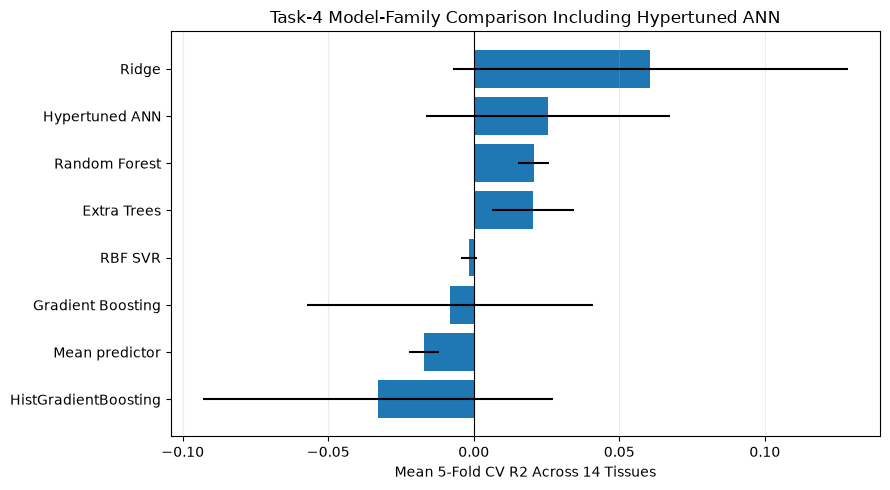

In [8]:
family_models = {
    "Mean predictor": mean_model,
    "Ridge": ridge_model,
    "Random Forest": RandomForestRegressor(n_estimators=150, min_samples_leaf=2,
                                            random_state=random_state, n_jobs=1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=150, min_samples_leaf=2,
                                        random_state=random_state, n_jobs=1),
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(n_estimators=100, random_state=random_state), n_jobs=1),
    "HistGradientBoosting": MultiOutputRegressor(
        HistGradientBoostingRegressor(max_iter=100, random_state=random_state), n_jobs=1),
    "RBF SVR": Pipeline([
        ("input_scaler", StandardScaler()),
        ("svr", MultiOutputRegressor(SVR(kernel="rbf", C=10), n_jobs=1)),
    ]),
}

family_rows = []
for name, model in family_models.items():
    start = perf_counter()
    scores = cross_val_score(model, X_train, Y_train, cv=cv, scoring="r2", n_jobs=1)
    family_rows.append({
        "Model": name, "Mean CV R2": scores.mean(), "Median fold R2": np.median(scores),
        "CV std": scores.std(), "Time (s)": perf_counter() - start,
    })
family_rows.append({
    "Model": "Hypertuned ANN", "Mean CV R2": ann_search.best_score_,
    "Median fold R2": np.nan, "CV std": ann_search.cv_results_["std_test_score"][ann_search.best_index_],
    "Time (s)": np.nan,
})
family_results = pd.DataFrame(family_rows).sort_values("Mean CV R2", ascending=False, ignore_index=True)
display(family_results.style.format(precision=6))

plt.figure(figsize=(9, 5))
plot_family = family_results.sort_values("Mean CV R2")
plt.barh(plot_family["Model"], plot_family["Mean CV R2"], xerr=plot_family["CV std"].fillna(0))
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Mean 5-Fold CV R2 Across 14 Tissues")
plt.title("Task-4 Model-Family Comparison Including Hypertuned ANN")
plt.grid(axis="x", alpha=0.25); plt.tight_layout(); plt.show()


#### Focused Tuning of the Other Leading Families and Final CV Winner

Ridge, Random Forest, and Extra Trees are tuned with small searches. Their best CV scores are compared directly with the already-hypertuned ANN. This fixes the final model family before any test prediction is calculated.


In [9]:
search_specs = {
    "Ridge": (
        Pipeline([("input_scaler", StandardScaler()), ("ridge", Ridge())]),
        {"ridge__alpha": loguniform(1e-4, 1e4)}, 16,
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=random_state, n_jobs=1),
        {"n_estimators": randint(120, 401), "max_depth": [None, 4, 8, 12, 20],
         "min_samples_leaf": randint(1, 9), "max_features": [0.5, 0.75, 1.0]}, 12,
    ),
    "Extra Trees": (
        ExtraTreesRegressor(random_state=random_state, n_jobs=1),
        {"n_estimators": randint(120, 401), "max_depth": [None, 4, 8, 12, 20],
         "min_samples_leaf": randint(1, 9), "max_features": [0.5, 0.75, 1.0]}, 12,
    ),
}

tuning_rows, fitted_searches = [], {}
for name, (estimator, distributions, iterations) in search_specs.items():
    search = RandomizedSearchCV(
        estimator, param_distributions=distributions, n_iter=iterations,
        scoring="r2", cv=cv, random_state=random_state, n_jobs=1,
    )
    start = perf_counter(); search.fit(X_train, Y_train)
    fitted_searches[name] = search
    params = {k: (v.item() if hasattr(v, "item") else v) for k, v in search.best_params_.items()}
    tuning_rows.append({"Model": name, "Best mean CV R2": search.best_score_,
                        "Best parameters": params, "Search time (s)": perf_counter()-start})

tuning_rows.append({"Model": "Hypertuned ANN", "Best mean CV R2": ann_search.best_score_,
                    "Best parameters": best_ann_params, "Search time (s)": np.nan})
tuning_results = pd.DataFrame(tuning_rows).sort_values("Best mean CV R2", ascending=False, ignore_index=True)
display(tuning_results.style.format({"Best mean CV R2": "{:.6f}", "Search time (s)": "{:.2f}"}))

best_family = tuning_results.iloc[0]["Model"]
if best_family == "Hypertuned ANN":
    best_raw_estimator = ann_search.best_estimator_
    best_hyperparameters = best_ann_params
    best_tuned_cv_r2 = ann_search.best_score_
else:
    best_raw_estimator = fitted_searches[best_family].best_estimator_
    best_hyperparameters = tuning_results.iloc[0]["Best parameters"]
    best_tuned_cv_r2 = fitted_searches[best_family].best_score_

print("Final CV-selected family:", best_family)
print("Best hyperparameters:", best_hyperparameters)
print(f"Best family mean CV R2: {best_tuned_cv_r2:.6f}")


,Model,Best mean CV R2,Best parameters,Search time (s)
0,Ridge,0.083068,{'ridge__alpha': 71.77141927992021},0.26
1,Hypertuned ANN,0.025549,"{'learning_rate_init': 0.0001, 'hidden_layer_sizes': (60, 30), 'alpha': 0.0001, 'activation': 'tanh'}",nan
2,Extra Trees,0.021796,"{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 178}",15.78
3,Random Forest,0.021726,"{'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 141}",40.56


Final CV-selected family: Ridge
Best hyperparameters: {'ridge__alpha': 71.77141927992021}
Best family mean CV R2: 0.083068


#### Physics-Inspired Input Features

Only existing inputs are transformed. The selected model is compared on raw and engineered training inputs using CV. No SAR output or test score participates in this decision.


In [10]:
def engineer_inputs(frame):
    result = frame.copy()
    epsilon_0, frequency = 8.8541878128e-12, 13.56e6
    omega = 2 * np.pi * frequency
    for tissue in tissue_names:
        eps = frame[f"Eps_{tissue}"].clip(lower=1e-12)
        cond = frame[f"Cond_{tissue}(S/m)"].clip(lower=1e-12)
        result[f"Ratio_Cond_over_Eps_{tissue}"] = cond / eps
        result[f"Product_Cond_Eps_{tissue}"] = cond * eps
        result[f"Log_Cond_{tissue}"] = np.log(cond)
        result[f"Log_Eps_{tissue}"] = np.log(eps)
        result[f"LossProxy_{tissue}"] = cond / (omega * epsilon_0 * eps)
    return result

X_train_engineered = engineer_inputs(X_train)
X_test_engineered = engineer_inputs(X_test)
raw_feature_scores = cross_val_score(clone(best_raw_estimator), X_train, Y_train,
                                     cv=cv, scoring="r2", n_jobs=1)
engineered_feature_scores = cross_val_score(clone(best_raw_estimator), X_train_engineered, Y_train,
                                            cv=cv, scoring="r2", n_jobs=1)
use_engineered_features = engineered_feature_scores.mean() > raw_feature_scores.mean()

feature_comparison = pd.DataFrame({
    "Feature set": ["Raw 28 inputs", f"Engineered {X_train_engineered.shape[1]} inputs"],
    "Mean CV R2": [raw_feature_scores.mean(), engineered_feature_scores.mean()],
    "CV std": [raw_feature_scores.std(), engineered_feature_scores.std()],
})
display(feature_comparison.style.format(precision=6))
print("Selected feature set:", "engineered" if use_engineered_features else "raw 28 inputs")


,Feature set,Mean CV R2,CV std
0,Raw 28 inputs,0.083068,0.052886
1,Engineered 98 inputs,0.071532,0.063284


Selected feature set: raw 28 inputs


#### Final Model and ANN Evaluations on the Held-Out Test Set

All model-family, hyperparameter, scaling, and feature decisions are now fixed. The selected overall model, the original ANN baseline, and the hypertuned ANN are fitted on all 400 training samples and evaluated on the same untouched 100 samples. These test results are reported for comparison but were not used for selection.


In [11]:
def per_tissue_metrics(y_true, y_pred):
    rows = []
    for j, tissue in enumerate(tissue_names):
        yt, yp = np.asarray(y_true)[:, j], np.asarray(y_pred)[:, j]
        rows.append({
            "Tissue": tissue, "R2": sm.r2_score(yt, yp),
            "MAE_mW/kg": sm.mean_absolute_error(yt, yp),
            "MSE_(mW/kg)^2": sm.mean_squared_error(yt, yp),
            "MedAE_mW/kg": sm.median_absolute_error(yt, yp),
            "Explained Variance": sm.explained_variance_score(yt, yp),
            "Pearson correlation": pearsonr(yt, yp)[0],
        })
    return pd.DataFrame(rows)

def metric_summary(model_name, y_train, train_prediction, y_test, test_prediction):
    table = per_tissue_metrics(y_test, test_prediction)
    return table, {
        "Model": model_name,
        "R2_train": sm.r2_score(y_train, train_prediction, multioutput="uniform_average"),
        "Mean test R2": table["R2"].mean(),
        "Median test R2": table["R2"].median(),
        "Mean MAE": table["MAE_mW/kg"].mean(),
        "Mean MSE": table["MSE_(mW/kg)^2"].mean(),
        "Mean MedAE": table["MedAE_mW/kg"].mean(),
        "Mean EV": table["Explained Variance"].mean(),
        "Mean Pearson": table["Pearson correlation"].mean(),
        "Best tissue": table.loc[table["R2"].idxmax(), "Tissue"],
        "Best tissue R2": table["R2"].max(),
        "Worst tissue": table.loc[table["R2"].idxmin(), "Tissue"],
        "Worst tissue R2": table["R2"].min(),
    }

# Overall CV winner.
final_model = clone(best_raw_estimator)
final_X_train = X_train_engineered if use_engineered_features else X_train
final_X_test = X_test_engineered if use_engineered_features else X_test
final_model.fit(final_X_train, Y_train)
train_pred = final_model.predict(final_X_train)
test_pred = final_model.predict(final_X_test)
final_tissue_metrics, final_summary = metric_summary(
    best_family, Y_train, train_pred, Y_test, test_pred
)

# Baseline and hypertuned ANN comparison, evaluated only after selection.
baseline_ann_model = clone(selected_ann_baseline).fit(X_train, Y_train)
tuned_ann_model = clone(ann_search.best_estimator_).fit(X_train, Y_train)
baseline_ann_train_pred = baseline_ann_model.predict(X_train)
baseline_ann_test_pred = baseline_ann_model.predict(X_test)
tuned_ann_train_pred = tuned_ann_model.predict(X_train)
tuned_ann_test_pred = tuned_ann_model.predict(X_test)
baseline_ann_tissue_metrics, baseline_ann_summary = metric_summary(
    "Baseline ANN", Y_train, baseline_ann_train_pred, Y_test, baseline_ann_test_pred
)
tuned_ann_tissue_metrics, tuned_ann_summary = metric_summary(
    "Hypertuned ANN", Y_train, tuned_ann_train_pred, Y_test, tuned_ann_test_pred
)

print("Y_test shape:", Y_test.shape)
print("Final model prediction shape:", test_pred.shape)
print("Hypertuned ANN prediction shape:", tuned_ann_test_pred.shape)
assert Y_test.shape == test_pred.shape == tuned_ann_test_pred.shape == (100, 14)

print("\nHypertuned ANN per-tissue metrics")
display(tuned_ann_tissue_metrics.style.format(precision=6))

ann_comparison = pd.DataFrame({
    "Metric": ["Architecture", "Input scaling", "Output scaling", "Activation", "Alpha",
               "Learning rate", "CV R2", "Train R2", "Mean test R2", "Mean MAE",
               "Mean MSE", "Mean EV", "Mean Pearson"],
    "Baseline ANN": ["28 -> 5 -> 14", "StandardScaler", ann_uses_target_scaling,
                     "tanh", 1e-4, 1e-2, baseline_ann_cv.mean(),
                     baseline_ann_summary["R2_train"], baseline_ann_summary["Mean test R2"],
                     baseline_ann_summary["Mean MAE"], baseline_ann_summary["Mean MSE"],
                     baseline_ann_summary["Mean EV"], baseline_ann_summary["Mean Pearson"]],
    "Hypertuned ANN": [best_ann_architecture, "StandardScaler", ann_uses_target_scaling,
                       best_ann_params["activation"], best_ann_params["alpha"],
                       best_ann_params["learning_rate_init"], ann_search.best_score_,
                       tuned_ann_summary["R2_train"], tuned_ann_summary["Mean test R2"],
                       tuned_ann_summary["Mean MAE"], tuned_ann_summary["Mean MSE"],
                       tuned_ann_summary["Mean EV"], tuned_ann_summary["Mean Pearson"]],
})
display(ann_comparison)

print("\nFinal selected-model per-tissue metrics")
display(final_tissue_metrics.style.format(precision=6))

mean_train_r2 = final_summary["R2_train"]
mean_test_r2 = final_summary["Mean test R2"]
median_test_r2 = final_summary["Median test R2"]
mean_mae, mean_mse = final_summary["Mean MAE"], final_summary["Mean MSE"]
mean_medae, mean_ev = final_summary["Mean MedAE"], final_summary["Mean EV"]
mean_pearson = final_summary["Mean Pearson"]
best_tissue = final_tissue_metrics.loc[final_tissue_metrics["R2"].idxmax()]
worst_tissue = final_tissue_metrics.loc[final_tissue_metrics["R2"].idxmin()]
r2_gap = mean_train_r2 - mean_test_r2
if r2_gap > 0.15 and mean_test_r2 < 0.5:
    generalization_assessment = "The large train-test gap with weak test R2 indicates overfitting."
elif mean_train_r2 < 0.3 and mean_test_r2 < 0.3:
    generalization_assessment = "Both train and test R2 are low, indicating underfitting or weak learnable signal."
elif r2_gap > 0.10:
    generalization_assessment = "The train-test gap indicates appreciable overfitting."
else:
    generalization_assessment = "The train-test gap is modest; generalization is broadly consistent with CV."

tuned_ann_gap = tuned_ann_summary["R2_train"] - tuned_ann_summary["Mean test R2"]
print(f"Final model mean train/test R2: {mean_train_r2:.6f} / {mean_test_r2:.6f}")
print(f"Final model R2 gap: {r2_gap:.6f}")
print(generalization_assessment)
print(f"Hypertuned ANN train-test R2 gap: {tuned_ann_gap:.6f}")


Y_test shape: (100, 14)
Final model prediction shape: (100, 14)
Hypertuned ANN prediction shape: (100, 14)

Hypertuned ANN per-tissue metrics


,Tissue,R2,MAE_mW/kg,MSE_(mW/kg)^2,MedAE_mW/kg,Explained Variance,Pearson correlation
0,blood,0.068863,0.050399,0.003634,0.046230,0.074406,0.288764
1,bodyAverage,0.074264,0.027845,0.001045,0.027761,0.086116,0.296381
2,boneCortical,0.074992,0.001131,0.000002,0.001125,0.079545,0.282544
3,brainGreyMatter,0.053889,0.015418,0.000327,0.013984,0.058131,0.267410
4,brainWhiteMatter,0.073836,0.007019,0.000082,0.005464,0.079364,0.340210
5,cartilage,0.161235,0.030405,0.001344,0.029029,0.163433,0.404320
6,cerebellum,0.094504,0.019704,0.000533,0.019261,0.097298,0.322533
7,cerebrospinalFluid,0.133839,0.196259,0.055580,0.183085,0.135096,0.368728
8,eyeVitrousHumor,0.201308,0.061341,0.005709,0.055112,0.210682,0.459393
9,fatAverageInfiltrated,-0.017392,0.002860,0.000012,0.002384,-0.016636,0.175496


,Metric,Baseline ANN,Hypertuned ANN
0,Architecture,28 -> 5 -> 14,28 -> 60 -> 30 -> 14
1,Input scaling,StandardScaler,StandardScaler
2,Output scaling,True,True
3,Activation,tanh,tanh
4,Alpha,0.0001,0.0001
5,Learning rate,0.01,0.0001
6,CV R2,-0.014942,0.025549
7,Train R2,0.081062,0.171518
8,Mean test R2,0.00319,0.069243
9,Mean MAE,0.034859,0.032819



Final selected-model per-tissue metrics


,Tissue,R2,MAE_mW/kg,MSE_(mW/kg)^2,MedAE_mW/kg,Explained Variance,Pearson correlation
0,blood,0.024682,0.052129,0.003806,0.045349,0.024885,0.222740
1,bodyAverage,0.109696,0.027795,0.001005,0.027105,0.117534,0.343017
2,boneCortical,0.212840,0.001040,0.000001,0.001086,0.213415,0.497165
3,brainGreyMatter,0.116310,0.014653,0.000305,0.013125,0.116685,0.343238
4,brainWhiteMatter,0.079433,0.007260,0.000081,0.005960,0.081747,0.317543
5,cartilage,0.134920,0.031153,0.001386,0.027088,0.138660,0.372405
6,cerebellum,0.110487,0.018975,0.000524,0.016966,0.112982,0.363519
7,cerebrospinalFluid,0.233167,0.183049,0.049206,0.169004,0.238277,0.491286
8,eyeVitrousHumor,0.087391,0.066835,0.006524,0.060165,0.097385,0.317033
9,fatAverageInfiltrated,0.062731,0.002729,0.000011,0.002581,0.064816,0.277287


Final model mean train/test R2: 0.202176 / 0.098218
Final model R2 gap: 0.103958
Both train and test R2 are low, indicating underfitting or weak learnable signal.
Hypertuned ANN train-test R2 gap: 0.102275


#### ANN and Final-Model Evaluation Plots

The hypertuned ANN loss curve is shown even if another family wins. The final-model scatter flattens all 100Ã—14 values only for visualization; the per-tissue table remains the evaluation basis.


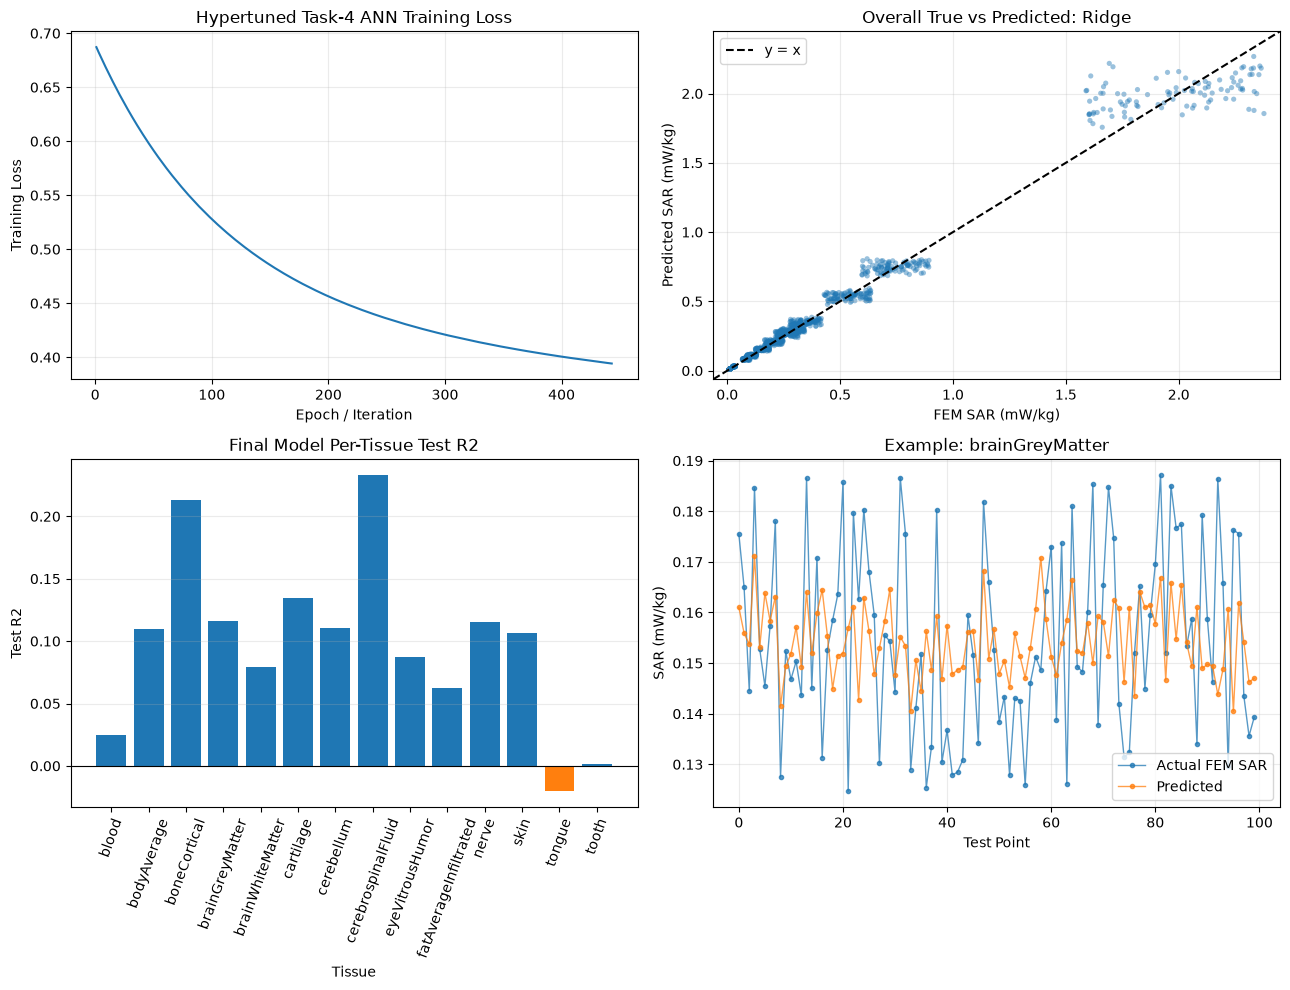

In [12]:
if ann_uses_target_scaling:
    tuned_mlp = tuned_ann_model.regressor_.named_steps["mlp"]
else:
    tuned_mlp = tuned_ann_model.named_steps["mlp"]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes[0, 0].plot(np.arange(1, len(tuned_mlp.loss_curve_)+1), tuned_mlp.loss_curve_)
axes[0, 0].set(xlabel="Epoch / Iteration", ylabel="Training Loss",
               title="Hypertuned Task-4 ANN Training Loss")
axes[0, 0].grid(alpha=0.25)

true_flat, pred_flat = Y_test.to_numpy().ravel(), test_pred.ravel()
lo, hi = min(true_flat.min(), pred_flat.min()), max(true_flat.max(), pred_flat.max())
pad = 0.03 * (hi-lo); limits = (lo-pad, hi+pad)
axes[0, 1].scatter(true_flat, pred_flat, s=14, alpha=0.45, edgecolor="none")
axes[0, 1].plot(limits, limits, "k--", label="y = x")
axes[0, 1].set(xlim=limits, ylim=limits, xlabel="FEM SAR (mW/kg)",
               ylabel="Predicted SAR (mW/kg)", title=f"Overall True vs Predicted: {best_family}")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.25)

colors = ["tab:blue" if value >= 0 else "tab:orange" for value in final_tissue_metrics["R2"]]
axes[1, 0].bar(tissue_names, final_tissue_metrics["R2"], color=colors)
axes[1, 0].axhline(0, color="black", lw=0.8)
axes[1, 0].set(xlabel="Tissue", ylabel="Test R2", title="Final Model Per-Tissue Test R2")
axes[1, 0].tick_params(axis="x", rotation=70); axes[1, 0].grid(axis="y", alpha=0.25)

j = tissue_names.index("brainGreyMatter"); points = np.arange(len(Y_test))
axes[1, 1].plot(points, Y_test.iloc[:, j], "o-", ms=3, lw=1, label="Actual FEM SAR", alpha=0.75)
axes[1, 1].plot(points, test_pred[:, j], "o-", ms=3, lw=1, label="Predicted", alpha=0.75)
axes[1, 1].set(xlabel="Test Point", ylabel="SAR (mW/kg)", title="Example: brainGreyMatter")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.25)
plt.tight_layout(); plt.show()


#### Permutation Sensitivity of the Selected Overall Model

Sensitivity is calculated only after selection. Permutation importance measures predictive dependence, not physical causality.


,Feature,Mean permutation importance,Std
0,Cond_nerve(S/m),0.028874,0.005338
1,Cond_cerebellum(S/m),0.024922,0.006171
2,Cond_cerebrospinalFluid(S/m),0.022983,0.005559
3,Cond_eyeVitrousHumor(S/m),0.020926,0.003756
4,Cond_cartilage(S/m),0.020568,0.004782
5,Cond_bodyAverage(S/m),0.019325,0.004415
6,Cond_boneCortical(S/m),0.018604,0.005103
7,Cond_skin(S/m),0.018103,0.003202
8,Cond_brainWhiteMatter(S/m),0.016216,0.006336
9,Cond_fatAverageInfiltrated(S/m),0.014684,0.004010


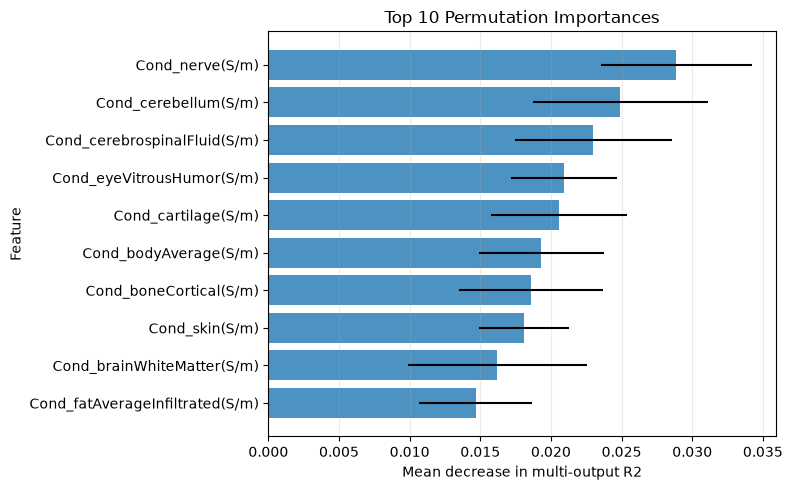

In [13]:
def macro_r2_scorer(estimator, x_values, y_values):
    return sm.r2_score(y_values, estimator.predict(x_values), multioutput="uniform_average")

importance = permutation_importance(
    final_model, final_X_test, Y_test, scoring=macro_r2_scorer,
    n_repeats=25, random_state=random_state, n_jobs=1,
)
importance_table = pd.DataFrame({
    "Feature": final_X_test.columns,
    "Mean permutation importance": importance.importances_mean,
    "Std": importance.importances_std,
}).sort_values("Mean permutation importance", ascending=False, ignore_index=True)
top_10 = importance_table.head(10)
display(top_10.style.format(precision=6))

plt.figure(figsize=(8, 5))
plot_imp = top_10.sort_values("Mean permutation importance")
plt.barh(plot_imp["Feature"], plot_imp["Mean permutation importance"],
         xerr=plot_imp["Std"], alpha=0.8)
plt.xlabel("Mean decrease in multi-output R2"); plt.ylabel("Feature")
plt.title("Top 10 Permutation Importances")
plt.grid(axis="x", alpha=0.25); plt.tight_layout(); plt.show()


#### Task-3 Comparison, Guiding Answers, and Final Summary


In [14]:
top_five = importance_table.head(5)["Feature"].tolist()
task3_reference_r2 = 0.993761
ann_hypertuning_improved_cv = ann_search.best_score_ > baseline_ann_cv.mean()
ann_hypertuning_improved_test = tuned_ann_summary["Mean test R2"] > baseline_ann_summary["Mean test R2"]
learnability_text = (
    "The new database contains some predictive signal, but prediction is weak and not robust enough for a high-quality surrogate."
    if mean_test_r2 > 0 else
    "The tested inputs do not provide robust out-of-sample predictive signal for these targets."
)
coupling_text = "strongly coupled" if mean_abs_output_corr > 0.7 else (
    "moderately coupled" if mean_abs_output_corr > 0.3 else "comparatively weakly coupled"
)

answers = f"""
### Did hypertuning the ANN improve Task 4?

| ANN result | Baseline | Hypertuned |
|---|---:|---:|
| Architecture | 28 -> 5 -> 14 | {best_ann_architecture} |
| Mean CV R2 | {baseline_ann_cv.mean():.6f} | {ann_search.best_score_:.6f} |
| Mean test R2 | {baseline_ann_summary['Mean test R2']:.6f} | {tuned_ann_summary['Mean test R2']:.6f} |

Hypertuning {'improved' if ann_hypertuning_improved_cv else 'did not improve'} ANN validation performance and {'improved' if ann_hypertuning_improved_test else 'did not improve'} its held-out mean R2. The best Task-4 ANN used `{best_ann_topology}`, `{best_ann_params['activation']}`, alpha `{best_ann_params['alpha']}`, and learning rate `{best_ann_params['learning_rate_init']}` with {'input and target scaling' if ann_uses_target_scaling else 'input scaling only'}.

### Guiding Questions

**What differs from Task 3?** Task 4 uses SAR calculated from only the scattered electric field; Task 3 used the physically meaningful total field.  
**How well is Task 4 predicted?** The CV-selected overall winner was {best_family}, with mean CV R2 {best_tuned_cv_r2:.6f} and final mean test R2 {mean_test_r2:.6f}. {learnability_text}  
**Which methods worked better?** {best_family} won the honest CV comparison. The raw 28-input feature set {'won' if not use_engineered_features else 'did not win'} the representation comparison. The outputs were {coupling_text} (mean absolute off-diagonal correlation {mean_abs_output_corr:.4f}).

### Task-3 Versus Task-4 ANN

Task 3 selected **28 -> 20 -> 14** and achieved mean test R2 â‰ˆ {task3_reference_r2:.6f}. The best Task-4 ANN selected **{best_ann_architecture}** and achieved mean test R2 {tuned_ann_summary['Mean test R2']:.6f}. The large measured difference supports the conclusion that the scattered-field-only Task-4 targets are much less learnable from these 28 material properties; it does not justify forcing a more complex network to memorize the training set.

### Compact Final Summary

| Item | Measured result |
|---|---|
| Dataset / train / test | {data_set.shape}; {len(X_train)} / {len(X_test)} |
| Inputs / outputs | {X.shape[1]} / {Y.shape[1]} |
| Baseline ANN CV / test R2 | {baseline_ann_cv.mean():.6f} / {baseline_ann_summary['Mean test R2']:.6f} |
| Best ANN architecture | {best_ann_architecture} |
| Best ANN CV / test R2 | {ann_search.best_score_:.6f} / {tuned_ann_summary['Mean test R2']:.6f} |
| Best ANN activation / alpha / learning rate | {best_ann_params['activation']} / {best_ann_params['alpha']} / {best_ann_params['learning_rate_init']} |
| ANN target scaling used? | {'Yes' if ann_uses_target_scaling else 'No'} |
| Overall winning family | {best_family} |
| Overall best parameters | {best_hyperparameters} |
| Engineered features used? | {'Yes' if use_engineered_features else 'No'} |
| Final mean / median test R2 | {mean_test_r2:.6f} / {median_test_r2:.6f} |
| Final mean MAE / MSE / MedAE | {mean_mae:.6f} / {mean_mse:.6f} / {mean_medae:.6f} |
| Final mean EV / Pearson | {mean_ev:.6f} / {mean_pearson:.6f} |
| Best / worst tissue | {best_tissue['Tissue']} ({best_tissue['R2']:.6f}) / {worst_tissue['Tissue']} ({worst_tissue['R2']:.6f}) |
| Final train-test R2 gap | {r2_gap:.6f} |
| Assessment | {generalization_assessment} |
| Top five important inputs | {', '.join(top_five)} |
| Task-3 / Task-4 best ANN test R2 | {task3_reference_r2:.6f} / {tuned_ann_summary['Mean test R2']:.6f} |

**Final conclusion:** {learnability_text} ANN hypertuning was performed fully and leakage-safely, and the ANN was allowed to compete for the overall win; the final result follows the measured CV ranking rather than a model-family assumption.
"""
display(Markdown(answers))



### Did hypertuning the ANN improve Task 4?

| ANN result | Baseline | Hypertuned |
|---|---:|---:|
| Architecture | 28 -> 5 -> 14 | 28 -> 60 -> 30 -> 14 |
| Mean CV R2 | -0.014942 | 0.025549 |
| Mean test R2 | 0.003190 | 0.069243 |

Hypertuning improved ANN validation performance and improved its held-out mean R2. The best Task-4 ANN used `(60, 30)`, `tanh`, alpha `0.0001`, and learning rate `0.0001` with input and target scaling.

### Guiding Questions

**What differs from Task 3?** Task 4 uses SAR calculated from only the scattered electric field; Task 3 used the physically meaningful total field.  
**How well is Task 4 predicted?** The CV-selected overall winner was Ridge, with mean CV R2 0.083068 and final mean test R2 0.098218. The new database contains some predictive signal, but prediction is weak and not robust enough for a high-quality surrogate.  
**Which methods worked better?** Ridge won the honest CV comparison. The raw 28-input feature set won the representation comparison. The outputs were comparatively weakly coupled (mean absolute off-diagonal correlation 0.0786).

### Task-3 Versus Task-4 ANN

Task 3 selected **28 -> 20 -> 14** and achieved mean test R2 â‰ˆ 0.993761. The best Task-4 ANN selected **28 -> 60 -> 30 -> 14** and achieved mean test R2 0.069243. The large measured difference supports the conclusion that the scattered-field-only Task-4 targets are much less learnable from these 28 material properties; it does not justify forcing a more complex network to memorize the training set.

### Compact Final Summary

| Item | Measured result |
|---|---|
| Dataset / train / test | (500, 42); 400 / 100 |
| Inputs / outputs | 28 / 14 |
| Baseline ANN CV / test R2 | -0.014942 / 0.003190 |
| Best ANN architecture | 28 -> 60 -> 30 -> 14 |
| Best ANN CV / test R2 | 0.025549 / 0.069243 |
| Best ANN activation / alpha / learning rate | tanh / 0.0001 / 0.0001 |
| ANN target scaling used? | Yes |
| Overall winning family | Ridge |
| Overall best parameters | {'ridge__alpha': 71.77141927992021} |
| Engineered features used? | No |
| Final mean / median test R2 | 0.098218 / 0.108215 |
| Final mean MAE / MSE / MedAE | 0.032180 / 0.004577 / 0.029229 |
| Final mean EV / Pearson | 0.106915 / 0.339611 |
| Best / worst tissue | cerebrospinalFluid (0.233167) / tongue (-0.020420) |
| Final train-test R2 gap | 0.103958 |
| Assessment | Both train and test R2 are low, indicating underfitting or weak learnable signal. |
| Top five important inputs | Cond_nerve(S/m), Cond_cerebellum(S/m), Cond_cerebrospinalFluid(S/m), Cond_eyeVitrousHumor(S/m), Cond_cartilage(S/m) |
| Task-3 / Task-4 best ANN test R2 | 0.993761 / 0.069243 |

**Final conclusion:** The new database contains some predictive signal, but prediction is weak and not robust enough for a high-quality surrogate. ANN hypertuning was performed fully and leakage-safely, and the ANN was allowed to compete for the overall win; the final result follows the measured CV ranking rather than a model-family assumption.
